In [22]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import sys
from wave_approx import *
import pickle
import matplotlib.gridspec as gs

%load_ext autoreload
%autoreload 2
mpl.rcParams.update({'font.family': 'CMU Sans Serif', 'axes.unicode_minus' : False})
mpl.rcParams.update({'mathtext.fontset': 'cm', 'mathtext.default':'it'})
def get_colors(n, sat0 = 0.3, val0 = 0.1, val1 = 1.0):
    sat_green = np.zeros((n,3))
    sat_red = np.zeros((n,3))
    sat_blue = np.zeros((n,3))
    sat_green[:,0] = 1/3
    sat_red[:,0] = 0
    sat_blue[:,0] = 2/3 

    #sat_green[:,1] = np.linspace(sat0, 1, n)
    sat_green[:,1] = sat0
    sat_green[:,2] = np.power(np.linspace(val0, val1, n), 0.5)
    #sat_green[:,2] = 0.5

    sat_red[:,1] = np.linspace(sat0, 1, n)
    #sat_red[:,1] = sat0
    #sat_red[:,2] = np.linspace(val0, val1, n)
    sat_red[:,2] = val1

    sat_blue[:,1] = np.linspace(sat0, 1, n)
    #sat_blue[:,1] = sat0
    #sat_blue[:,2] = np.linspace(val0, val1, n)
    sat_blue[:,2] = val1
    greens = mpl.colors.hsv_to_rgb(sat_green)
    reds = mpl.colors.hsv_to_rgb(sat_red)
    blues = mpl.colors.hsv_to_rgb(sat_blue)
    sat_black = np.zeros((n,3))
    sat_black[:,0] = 1/3
    sat_black[:,1] = 0
    sat_black[:,2] = np.linspace(val0, val1-val0, n)#0.1
    blacks = mpl.colors.hsv_to_rgb(sat_black)
    return greens, reds, blues, blacks

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
quad = False
rLTD = 0.3
r0 = 6
rx = 20
l = 8
#d = 15/20*8
d = 10/20*l
#d = 5/20*8
v = 3.2
k = 0.114*0.017
A = 0.001
tau_m = 0.02
tau = 1
gL = 40
w0 = 0.06581
cap = 0
shape = 'circle'
match shape:
    case 'circle':
        half_func = half_circle_height
        iint_func = iint_circle_chord
        int_func = int_circle_chord
        if quad:
            func = half_circle_height
        else:
            func = iint_circle_chord
    case 'square':
        half_func = half_square
        iint_func = iint_square
        int_func = int_square
        if quad:
            func = half_square
        else:
            func = iint_square
 

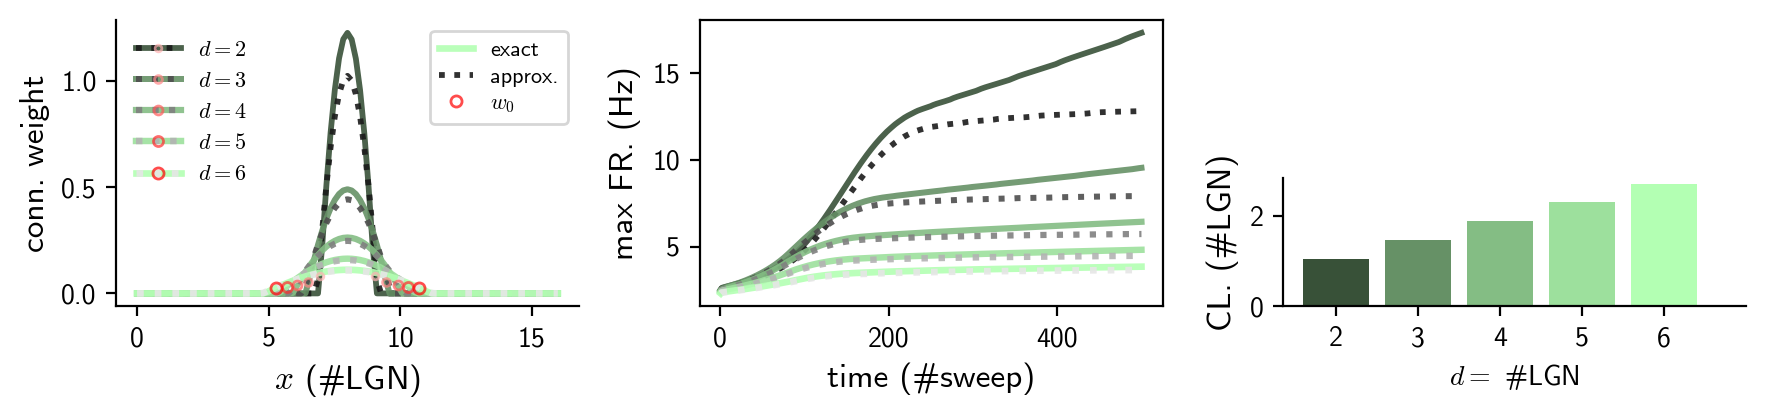

In [47]:
theme = 'width'
with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'rb') as f:
    w_range, nT_range, d_range, deg_r, l, nx, dT, wt, fr = pickle.load(f)
grid = gs.GridSpec(ncols = 3, nrows = 2, width_ratios = [1,1,1])
fig = plt.figure(figsize = (9,2.2), dpi = 200)
ax0 = fig.add_subplot(grid[:,0])
ax1 = fig.add_subplot(grid[:,1])
ax2 = fig.add_subplot(grid[1,2])
#n = 3

FS = 12
fs = 8
n = len(d_range)
dw = 0.4
lw0 = 2
ms0 = 2
dms = 2
c, mc, _, ac = get_colors(n)
exact = []
approx = []
iv = []
for i in range(n):
    lbl = r''
    x = np.linspace(0,2*l,nx)
    exact.append(ax0.plot(x, wt[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9))
    approx.append(ax0.plot(x, wt[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9))
    ax1.plot(np.arange(nT_range[i])+1, fr[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9)
    ax1.plot(np.arange(nT_range[i]*dT)/dT+1, fr[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9)
        
for i in range(n):
    xl = np.nonzero(wt[0][i] - w_range[i] > 0)[0][0]
    xr = nx - 1 - np.nonzero(np.flip(wt[0][i]) - w_range[i] > 0)[0][0]
    if xl > 0:
        xl = x[xl-1] + (w_range[i] - wt[0][i][xl-1])/(wt[0][i][xl] - wt[0][i][xl-1])*(x[1]-x[0])
    else:
        xl = x[xl]
    if xr < nx-1:
        xr = x[xr+1] - (w_range[i] - wt[0][i][xr+1])/(wt[0][i][xr] - wt[0][i][xr+1])*(x[1]-x[0])
    else:
        xr = x[xr]
    iv.append(ax0.plot([xl, xr], [w_range[i],w_range[i]], 'o', fillstyle = 'none', color = mc[i], ms = ms0 + (i+1)/n * dms, alpha = 0.7))
    ax2.bar(i+0.5, (xr-xl)/2, color = c[i])
    
#ax2.set_ylim([0, l])
ax2.set_xticks(np.arange(n)+0.5, [f'{_d/deg_r*l:.0f}' for _d in d_range])
ax2.set_xlabel(r'$d =$ #LGN', fontsize = fs+2)
ax2.set_ylabel('CL. (#LGN)', fontsize = FS)
ax2.set_xlim(right = n + 0.5)
ax0.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
leg1 = ax0.legend([(eh[0], ah[0], ih[0]) for eh, ah, ih in zip(exact, approx, iv)], [rf'$d = {d_range[i]/deg_r*l:.0f}$' for i in range(n)], loc = 'upper left', fontsize = fs, frameon = False)
ax0.add_artist(leg1)
ax0.legend([exact[-1][0], approx[0][0], iv[-1][0]], ['exact', 'approx.', r'$w_0$'], fontsize=fs, handlelength = 1.5, labelspacing = 0.3)
ax0.set_xlabel(r'$x$ (#LGN)', fontsize = FS)
ax0.set_ylabel('conn. weight', fontsize = FS)
ax1.set_xlabel('time (#sweep)', fontsize = FS)
ax1.set_ylabel('max FR. (Hz)', fontsize = FS)
fig.tight_layout()
fig.savefig(f'{theme}-homeo2.png')
fig.savefig(f'{theme}-homeo2.svg')

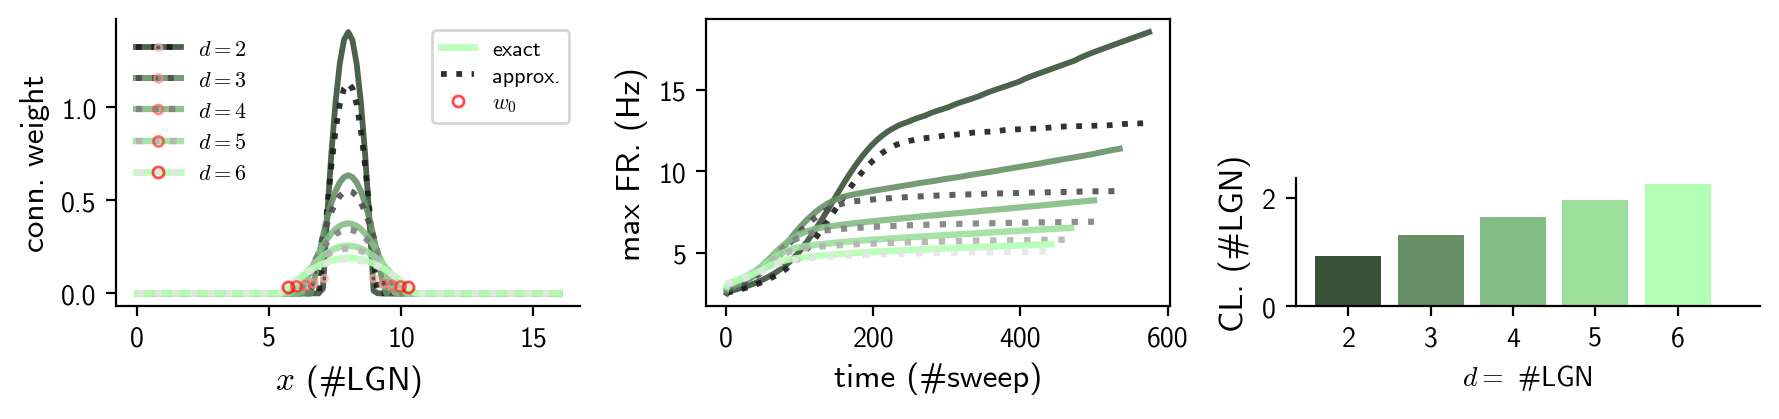

In [48]:
theme = 'width-same_per_t'
with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'rb') as f:
    w_range, nT_range, d_range, deg_r, l, nx, dT, wt, fr = pickle.load(f)
grid = gs.GridSpec(ncols = 3, nrows = 2, width_ratios = [1,1,1])
fig = plt.figure(figsize = (9,2.2), dpi = 200)
ax0 = fig.add_subplot(grid[:,0])
ax1 = fig.add_subplot(grid[:,1])
ax2 = fig.add_subplot(grid[1,2])
#n = 3

FS = 12
fs = 8
n = len(d_range)
dw = 0.4
lw0 = 2
ms0 = 2
dms = 2
c, mc, _, ac = get_colors(n)
exact = []
approx = []
iv = []
for i in range(n):
    lbl = r''
    x = np.linspace(0,2*l,nx)
    exact.append(ax0.plot(x, wt[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9))
    approx.append(ax0.plot(x, wt[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9))
    ax1.plot(np.arange(nT_range[i])+1, fr[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9)
    ax1.plot(np.arange(nT_range[i]*dT)/dT+1, fr[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9)
        
for i in range(n):
    xl = np.nonzero(wt[0][i] - w_range[i] > 0)[0][0]
    xr = nx - 1 - np.nonzero(np.flip(wt[0][i]) - w_range[i] > 0)[0][0]
    if xl > 0:
        xl = x[xl-1] + (w_range[i] - wt[0][i][xl-1])/(wt[0][i][xl] - wt[0][i][xl-1])*(x[1]-x[0])
    else:
        xl = x[xl]
    if xr < nx-1:
        xr = x[xr+1] - (w_range[i] - wt[0][i][xr+1])/(wt[0][i][xr] - wt[0][i][xr+1])*(x[1]-x[0])
    else:
        xr = x[xr]
    iv.append(ax0.plot([xl, xr], [w_range[i],w_range[i]], 'o', fillstyle = 'none', color = mc[i], ms = ms0 + (i+1)/n * dms, alpha = 0.7))
    ax2.bar(i+0.5, (xr-xl)/2, color = c[i])
    
#ax2.set_ylim([0, l])
ax2.set_xticks(np.arange(n)+0.5, [f'{_d/deg_r*l:.0f}' for _d in d_range])
ax2.set_xlabel(r'$d =$ #LGN', fontsize = fs+2)
ax2.set_ylabel('CL. (#LGN)', fontsize = FS)
ax2.set_xlim(right = n + 0.5)
ax0.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
leg1 = ax0.legend([(eh[0], ah[0], ih[0]) for eh, ah, ih in zip(exact, approx, iv)], [rf'$d = {d_range[i]/deg_r*l:.0f}$' for i in range(n)], loc = 'upper left', fontsize = fs, frameon = False)
ax0.add_artist(leg1)
ax0.legend([exact[-1][0], approx[0][0], iv[-1][0]], ['exact', 'approx.', r'$w_0$'], fontsize=fs, handlelength = 1.5, labelspacing = 0.3)
ax0.set_xlabel(r'$x$ (#LGN)', fontsize = FS)
ax0.set_ylabel('conn. weight', fontsize = FS)
ax1.set_xlabel('time (#sweep)', fontsize = FS)
ax1.set_ylabel('max FR. (Hz)', fontsize = FS)
fig.tight_layout()
fig.savefig(f'{theme}-homeo2.png')
fig.savefig(f'{theme}-homeo2.svg')

w0 = 0.15, nT_range = [ 50 100 200 300 400], v_range = [ 1.6  3.2  6.4  9.6 12.8], L = 30.627416997969522, l = 8, nx = 101, dT = 1


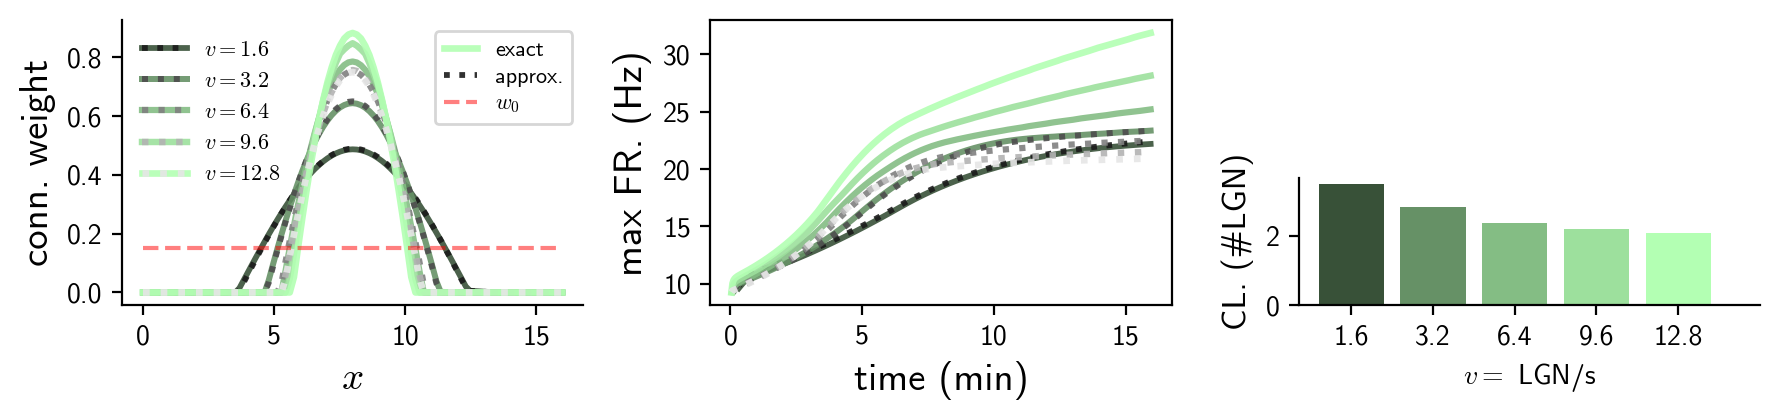

In [21]:
theme = 'speed'
with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'rb') as f:
    w0, nT_range, v_range, L, l, nx, dT, wt_v, fr_v = pickle.load(f)
print(f'w0 = {w0}, nT_range = {nT_range}, v_range = {v_range}, L = {L}, l = {l}, nx = {nx}, dT = {dT}')
grid = gs.GridSpec(ncols = 3, nrows = 2, width_ratios = [1,1,1])
fig = plt.figure(figsize = (9,2.2), dpi = 200)
ax0 = fig.add_subplot(grid[:,0])
ax1 = fig.add_subplot(grid[:,1])
ax2 = fig.add_subplot(grid[1,2])
FS = 12
fs = 8
n = len(v_range)
dw = 0.4
lw0 = 2
ms0 = 2
dms = 2
c, mc, _, ac = get_colors(n)
exact = []
approx = []
for i in range(n):
    lbl = r''
    T = L/v_range[i]
    x = np.linspace(0,2*l,nx)
    exact.append(ax0.plot(x, wt_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9))
    approx.append(ax0.plot(x, wt_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9))
    ax1.plot((np.arange(nT_range[i])+1)*T/60, fr_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9)
    ax1.plot((np.arange(nT_range[i]*dT)/dT+1)*T/60, fr_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9)

#iv = []
for i in range(n):
    xl = np.nonzero(wt_v[0][i] - w0 > 0)[0][0]
    xr = nx - 1 - np.nonzero(np.flip(wt_v[0][i]) - w0 > 0)[0][0]
    if xl > 0:
        xl = x[xl-1] + (w0 - wt_v[0][i][xl-1])/(wt_v[0][i][xl] - wt_v[0][i][xl-1])*(x[1]-x[0])
    else:
        xl = x[xl]
    if xr < nx-1:
        xr = x[xr+1] - (w0 - wt_v[0][i][xr+1])/(wt_v[0][i][xr] - wt_v[0][i][xr+1])*(x[1]-x[0])
    else:
        xr = x[xr]
    #iv.append(ax0.plot([xl, xr], [w0, w0], 'o', fillstyle = 'none', color = mc[i], ms = ms0 + (i+1)/n * dms, alpha = 0.7))
    ax2.bar(i+0.5, (xr-xl)/2, color = c[i])
iv = ax0.plot([x[0], x[-1]], [w0, w0], '--r', ms = ms0, alpha = 0.5)
    
#ax2.set_ylim([0, l])
ax2.set_xticks(np.arange(n)+0.5, [f'{_v/deg_r}' for _v in v_range])
ax2.set_xlabel(r'$v =$ LGN/s', fontsize = fs+2)
ax2.set_ylabel('CL. (#LGN)', fontsize = FS)
ax2.set_xlim(right = n + 0.5)
ax0.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
#leg1 = ax0.legend([(eh[0], ah[0], ih[0]) for eh, ah, ih in zip(exact, approx, iv)], [rf'$v = {v_range[i]}$' for i in range(n)], loc = 'upper left', fontsize = fs, frameon = False)
leg1 = ax0.legend([(eh[0], ah[0]) for eh, ah in zip(exact, approx)], [rf'$v = {v_range[i]}$' for i in range(n)], loc = 'upper left', fontsize = fs, frameon = False)
ax0.add_artist(leg1)
#ax0.legend([exact[-1][0], approx[0][0], iv[-1][0]], ['exact', 'approx.', r'$w_0$'], fontsize=fs+2, handlelength = 1.5, labelspacing = 0.3)
ax0.legend([exact[-1][0], approx[0][0], iv[0]], ['exact', 'approx.', r'$w_0$'], fontsize=fs, handlelength = 1.5, labelspacing = 0.3)
ax0.set_xlabel(r'$x$', fontsize = FS+2)
ax0.set_ylabel('conn. weight', fontsize = FS+2)
ax1.set_xlabel('time (min)', fontsize = FS+2)
ax1.set_ylabel('max FR. (Hz)', fontsize = FS+2)
fig.tight_layout()
fig.savefig(f'{theme}-homeo2.png')
fig.savefig(f'{theme}-homeo2.svg')

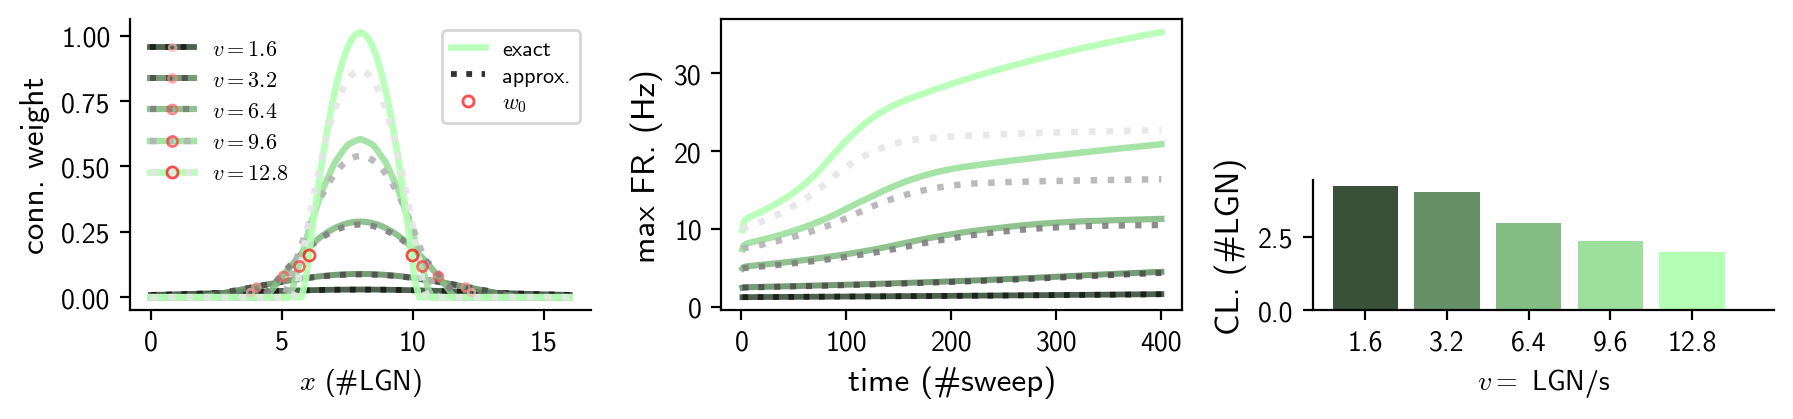

In [43]:
plt.rcParams['font.family'] = 'CMU Sans Serif'
plt.rcParams['mathtext.fontset'] = 'cm'
theme = 'speed-same_sweep'
with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'rb') as f:
    w_range, nT_range, v_range, L, l, nx, dT, wt_v, fr_v = pickle.load(f)
grid = gs.GridSpec(ncols = 3, nrows = 2, width_ratios = [1,1,1])
fig = plt.figure(figsize = (9,2.2), dpi = 200)
ax0 = fig.add_subplot(grid[:,0])
ax1 = fig.add_subplot(grid[:,1])
ax2 = fig.add_subplot(grid[1,2])
FS = 12
fs = 8
n = len(v_range)
dw = 0.4
lw0 = 2
ms0 = 2
dms = 2
c, mc, _, ac = get_colors(n)
exact = []
approx = []
iv = []
for i in range(n):
    lbl = r''
    T = L/v_range[i]
    x = np.linspace(0,2*l,nx)
    exact.append(ax0.plot(x, wt_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9))
    approx.append(ax0.plot(x, wt_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9))
    if theme == 'speed-same_sweep':
        ax1.plot(np.arange(nT_range[i])+1, fr_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9)
        ax1.plot(np.arange(nT_range[i]*dT)/dT+1, fr_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9)
    else:
        ax1.plot((np.arange(nT_range[i])+1)*T/60, fr_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9)
        ax1.plot((np.arange(nT_range[i]*dT)/dT+1)*T/60, fr_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9)
        
for i in range(n):
    xl = np.nonzero(wt_v[0][i] - w_range[i] > 0)[0][0]
    xr = nx - 1 - np.nonzero(np.flip(wt_v[0][i]) - w_range[i] > 0)[0][0]
    if xl > 0:
        xl = x[xl-1] + (w_range[i] - wt_v[0][i][xl-1])/(wt_v[0][i][xl] - wt_v[0][i][xl-1])*(x[1]-x[0])
    else:
        xl = x[xl]
    if xr < nx-1:
        xr = x[xr+1] - (w_range[i] - wt_v[0][i][xr+1])/(wt_v[0][i][xr] - wt_v[0][i][xr+1])*(x[1]-x[0])
    else:
        xr = x[xr]
    iv.append(ax0.plot([xl, xr], [w_range[i], w_range[i]], 'o', fillstyle = 'none', color = mc[i], ms = ms0 + (i+1)/n * dms, alpha = 0.7))
    ax2.bar(i+0.5, (xr-xl)/2, color = c[i])
    
#ax2.set_ylim([0, l])
ax2.set_xticks(np.arange(n)+0.5, [f'{_v}' for _v in v_range])
ax2.set_xlabel(r'$v =$ LGN/s', fontsize = fs+2)
ax2.set_ylabel('CL. (#LGN)', fontsize = FS)
ax2.set_xlim(right = n + 0.5)
ax0.spines[['right', 'top']].set_visible(False)
ax2.spines[['right', 'top']].set_visible(False)
leg1 = ax0.legend([(eh[0], ah[0], ih[0]) for eh, ah, ih in zip(exact, approx, iv)], [rf'$v = {v_range[i]}$' for i in range(n)], loc = 'upper left', fontsize = fs, frameon = False)
ax0.add_artist(leg1)
ax0.legend([exact[-1][0], approx[0][0], iv[-1][0]], ['exact', 'approx.', r'$w_0$'], fontsize=fs, handlelength = 1.5, labelspacing = 0.3)
ax0.set_xlabel(r'$x$ (#LGN)')
ax0.set_ylabel('conn. weight', fontsize = FS)
if theme == 'speed-same_sweep':
    ax1.set_xlabel('time (#sweep)', fontsize = FS)
else:
    ax1.set_xlabel('time (min)', fontsize = FS)
ax1.set_ylabel('max FR. (Hz)', fontsize = FS)
fig.tight_layout()
fig.savefig(f'{theme}-homeo2.png')
fig.savefig(f'{theme}-homeo2.svg')

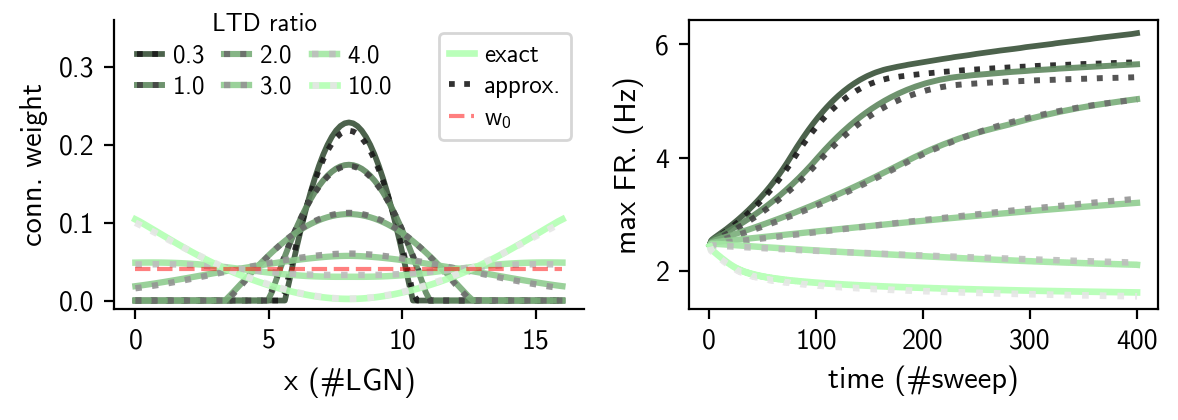

In [32]:
plt.rcParams['font.family'] = 'CMU Sans Serif'
plt.rcParams['mathtext.fontset'] = 'cm'
#theme = 'ltd_ratio'
theme = 'ltd_ratio6'
exact_only = False 
with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'rb') as f:
    ltd_ratio_range, w_range, nT_range, v_range, L, l, nx, dT, wt_v, fr_v = pickle.load(f)
grid = gs.GridSpec(ncols = 2, nrows = 2, width_ratios = [1,1])
fig = plt.figure(figsize = (6,2.2), dpi = 200)
ax0 = fig.add_subplot(grid[:,0])
ax1 = fig.add_subplot(grid[:,1])
FS = 11
fs = 9
n = len(v_range)
dw = 0.4
lw0 = 2
ms0 = 2
dms = 2
c, mc, _, ac = get_colors(n)
exact = []
approx = []
iv = []
x = np.linspace(0,2*l,nx)
for i in range(n):
    lbl = r''
    T = L/v_range[i]
    exact.append(ax0.plot(x, wt_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9))
    if not exact_only:
        approx.append(ax0.plot(x, wt_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9))
    ax1.plot(np.arange(nT_range[i])+1, fr_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9)
    if not exact_only:
        ax1.plot(np.arange(nT_range[i]*dT)/dT+1, fr_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9)
        
#for i in range(n):
#    xl = np.nonzero(wt_v[0][i] - w_range[i] > 0)[0][0]
#    xr = nx - 1 - np.nonzero(np.flip(wt_v[0][i]) - w_range[i] > 0)[0][0]
#    if xl > 0:
#        xl = x[xl-1] + (w_range[i] - wt_v[0][i][xl-1])/(wt_v[0][i][xl] - wt_v[0][i][xl-1])*(x[1]-x[0])
#    else:
#        xl = x[xl]
#    if xr < nx-1:
#        xr = x[xr+1] - (w_range[i] - wt_v[0][i][xr+1])/(wt_v[0][i][xr] - wt_v[0][i][xr+1])*(x[1]-x[0])
#    else:
#        xr = x[xr]
#    iv.append(ax0.plot([xl, xr], [w_range[i], w_range[i]], 'o', fillstyle = 'none', color = mc[i], ms = ms0 + (i+1)/n * dms, alpha = 0.7))
#    ax2.bar(i+0.5, (xr-xl)/2, color = c[i])
iv.append(ax0.plot(x, np.zeros(nx) + w_range[0], '--r', alpha = 0.5))
    
ax0.spines[['right', 'top']].set_visible(False)

if not exact_only:
    leg1 = ax0.legend([(eh[0], ah[0]) for eh, ah in zip(exact, approx)], [rf'${ltd_ratio_range[i]}$' for i in range(n)], loc = 'lower left', fontsize = fs, frameon = False, title = 'LTD ratio', title_fontsize = fs, bbox_to_anchor = [0.0, 0.65], handlelength = 1.0, labelspacing = 0.3, handletextpad = 0.4, ncols = 3, columnspacing = 0.8)
else:
    leg1 = ax0.legend([eh[0] for eh in exact], [rf'${ltd_ratio_range[i]}$' for i in range(n)], loc = 'lower left', fontsize = fs, frameon = False, title = 'LTD ratio', title_fontsize = fs, bbox_to_anchor = [0.09, 0.4], handlelength = 1.0, handletextpad = 0.4, labelspacing = 0.3)
ax0.add_artist(leg1)
if not exact_only:
    ax0.legend([exact[-1][0], approx[0][0], iv[-1][0]], ['exact', 'approx.', r'$w_0$'], fontsize=fs, handlelength = 1.0, labelspacing = 0.3, handletextpad = 0.4)
else:
    ax0.legend([exact[-1][0], iv[-1][0]], ['exact', r'$w_0$'], fontsize=fs, handlelength = 1.0, labelspacing = 0.3)
ax0.set_ylim(top = ax0.get_ylim()[1]*1.5)
ax0.set_xlabel(r'$x$ (#LGN)', fontsize = FS)
ax0.set_ylabel('conn. weight', fontsize = FS)
ax1.set_xlabel('time (#sweep)', fontsize = FS)
ax1.set_ylabel('max FR. (Hz)', fontsize = FS)
ax0.tick_params(axis = 'both', labelsize = fs+1)
ax1.tick_params(axis = 'both', labelsize = fs+1)
fig.tight_layout()
fig.savefig(f'{theme}-homeo2.png')
fig.savefig(f'{theme}-homeo2.svg')

/tmp/ipykernel_3136501/568139652.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  xr = x[xr+1] - (w_range[i] - wt_v[0][i][xr+1])/(wt_v[0][i][xr] - wt_v[0][i][xr+1])*(x[1]-x[0])


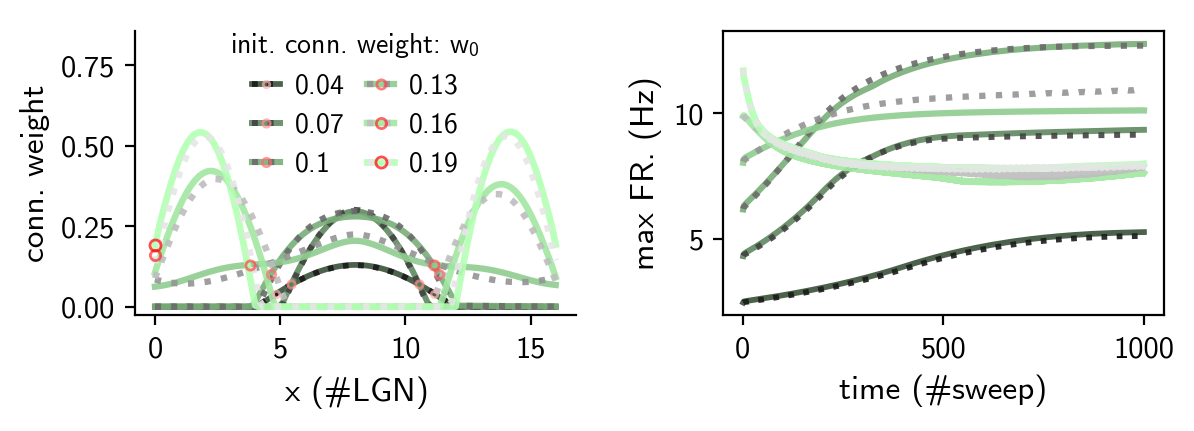

In [34]:
plt.rcParams['font.family'] = 'CMU Sans Serif'
plt.rcParams['mathtext.fontset'] = 'cm'
theme = 'w0'
exact_only = False 
with open(f'{theme}-exact2_vs_approx2_homeo2.pkl', 'rb') as f:
    ltd_ratio_range, w_range, nT_range, v_range, L, l, nx, dT, wt_v, fr_v = pickle.load(f)
grid = gs.GridSpec(ncols = 2, nrows = 2, width_ratios = [1,1])
fig = plt.figure(figsize = (6,2.2), dpi = 200)
ax0 = fig.add_subplot(grid[:,0])
ax1 = fig.add_subplot(grid[:,1])
FS = 12
fs = 10
n = len(v_range)
dw = 0.4
lw0 = 2
ms0 = 2
dms = 2
c, mc, _, ac = get_colors(n)
exact = []
approx = []
iv = []
x = np.linspace(0,2*l,nx)
for i in range(n):
    lbl = r''
    T = L/v_range[i]
    exact.append(ax0.plot(x, wt_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9))
    if not exact_only:
        approx.append(ax0.plot(x, wt_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9))
    ax1.plot(np.arange(nT_range[i])+1, fr_v[0][i], '-', lw = lw0 + (i+1)/n * dw, color = c[i], alpha = 0.9)
    if not exact_only:
        ax1.plot(np.arange(nT_range[i]*dT)/dT+1, fr_v[1][i], ':', lw = lw0 + (i+1)/n * dw, color = ac[i], alpha = 0.9)
        
for i in range(n):
    if np.abs(np.argmax(wt_v[0][i]) - nx//2) < nx//4:
        xl = np.nonzero(wt_v[0][i] - w_range[i] > 0)[0][0]
        xr = nx - 1 - np.nonzero(np.flip(wt_v[0][i]) - w_range[i] > 0)[0][0]
    else:
        xl = np.nonzero(wt_v[0][i][:nx//2] - w_range[i] < 0)[0][0]
        xr = nx//2 - 1 + np.nonzero(np.flip(wt_v[0][i][nx//2:]) - w_range[i] < 0)[0][0]
        
    if xl > 0:
        xl = x[xl-1] + (w_range[i] - wt_v[0][i][xl-1])/(wt_v[0][i][xl] - wt_v[0][i][xl-1])*(x[1]-x[0])
    else:
        xl = x[xl]
    if xr < nx-1:
        xr = x[xr+1] - (w_range[i] - wt_v[0][i][xr+1])/(wt_v[0][i][xr] - wt_v[0][i][xr+1])*(x[1]-x[0])
    else:
        xr = x[xr]
        
    iv.append(ax0.plot([xl, xr], [w_range[i], w_range[i]], 'o', fillstyle = 'none', color = mc[i], ms = ms0 + (i+1)/n * dms, alpha = 0.7))
    #ax2.bar(i+0.5, (xr-xl)/2, color = c[i])
    
ax0.spines[['right', 'top']].set_visible(False)

if not exact_only:
    ax0.legend([(eh[0], ah[0], vh[0]) for eh, ah, vh in zip(exact, approx, iv)], [rf'${w_range[i]}$' for i in range(n)], loc = 'lower center', fontsize = fs, frameon = False, handlelength = 1, bbox_to_anchor = (0.5, 0.4), ncol = 2, title = r'init. conn. weight: $w_0$', columnspacing = 0.8, handletextpad = 0.5)
else:
    ax0.legend([(eh[0], vh[0]) for eh, vh in zip(exact, vh)], [rf'${w_range[i]}$' for i in range(n)], loc = 'lower center', fontsize = fs, frameon = False, handlelength = 1.5, bbox_to_anchor = (0.5, 0.6), ncol = 2, title = r'init. conn. weight: $w_0$')
    
ax0.set_ylim(top = ax0.get_ylim()[1]*1.5)
ax0.set_xlabel(r'$x$ (#LGN)', fontsize = FS)
ax0.set_ylabel('conn. weight', fontsize = FS)
ax1.set_xlabel('time (#sweep)', fontsize = FS)
ax1.set_ylabel('max FR. (Hz)', fontsize = FS)
ax0.tick_params(axis = 'both', labelsize = fs+1)
ax1.tick_params(axis = 'both', labelsize = fs+1)
fig.tight_layout()
fig.savefig(f'{theme}-homeo2.png')
fig.savefig(f'{theme}-homeo2.svg')